# VANGUARDS DIGITAL CLIENT COMPLETION ANALYSIS

## 1. DATA CLEANING OF EACH INDIVIDUAL DATASET

### 1.1 WEB DATA DATASET

In [41]:
import pandas as pd

df1 = pd.read_csv("/Users/victoriacano/Downloads/df_final_web_data_pt_1.txt", sep=",")
df2 = pd.read_csv("/Users/victoriacano/Downloads/df_final_web_data_pt_2.txt", sep=",")

df1
df2


df_web_data = pd.concat([df1, df2], axis=0, join="outer")

df_web_data["client_id"] = pd.to_numeric(df_web_data["client_id"], errors='coerce', downcast='integer')
df_web_data["client_id"] = df_web_data["client_id"].astype("Int64")
df_web_data["date_time"] = pd.to_datetime(df_web_data["date_time"])

df_web_data.dtypes

#Checking for null values 
df_web_data.isnull().values.any()

df_web_data["client_id"].isnull().sum()
df_web_data["visitor_id"].isnull().sum()
df_web_data["visit_id"].isnull().sum()
df_web_data["process_step"].isnull().sum()
df_web_data["date_time"].isnull().sum()

#Check for duplicates:

df_web_data_duplicates = df_web_data[df_web_data.duplicated('client_id')]
df_web_data_duplicates

#When checking for client_id duplicates many appear but the date_time and process are different because the same client may have tried to carry out a step again 

#Total number of clients in the dataset (clients that did the process)

total_clients = df_web_data["client_id"].nunique()
print(f"Total number of clients in the dataset: {total_clients}")

#Checking how many clients redid confirmed step to only keep the last one as the end of the process 

confirmed = df_web_data[df_web_data["process_step"] == "confirm"]
counts = confirmed.groupby("client_id").size()

counts.sort_values(ascending=False)
df_web_data.to_csv("../data/clean/clean_web_data.csv", index=False)
df_web_data_duplicates1 = df_web_data[df_web_data["client_id"].duplicated()]
df_web_data_duplicates1

Total number of clients in the dataset: 120157


,client_id,visitor_id,visit_id,process_step,date_time
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
...,...,...,...,...,...
412258,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:48:02
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51


### 1.2 Data Demographics: 

In [42]:
import pandas as pd

df = pd.read_csv("../data/raw/df_final_demo.txt", sep=',')
df.head()

df.info() #the 'bal' column is not right because it's casted as string and it should be numerical

# checking for unique values
df.nunique()

# checking the unique values for gender
df['gendr'].value_counts()

# checking the ages of the clients
df['clnt_age'].describe()
df[df['clnt_age'] < 18].shape[0]
df[df['clnt_age'] < 18].shape[0]
df.shape

# there is just a few missing values, so let's drop them
df.dropna().shape 
df = df.dropna()
df = df.dropna()
df.shape
df.to_csv("../data/clean/df_final_demo.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: '../raw/df_final_demo.txt'

### 1.3 FINAL EXPERIMENT CLIENTS 


In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/df_final_experiment_clients.txt")

df.head()
df.info()
df.describe()


import pandas as pd

# 1. Load the file correctly
df = pd.read_csv("../raw/df_final_experiment_clients.txt")

# 2. Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# 3. Quick checks
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types before cleaning:")
print(df.dtypes)

print("\nMissing values before cleaning:")
print(df.isna().sum())

print("\nDuplicate rows before cleaning:", df.duplicated().sum())

print("\nUnique values in variation before cleaning:")
print(df["variation"].value_counts(dropna=False))


# 4. Fix column types
df["client_id"] = pd.to_numeric(df["client_id"], errors="coerce").astype("Int64")

# 5. Standardize categories
df["variation"] = df["variation"].astype("string").str.strip().str.title()

# 6. Handle missing values
# Here we keep missing values as "Missing" so you don't lose rows
df["variation"] = df["variation"].fillna("Missing")

# 7. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# 8. Final checks
print("\nData types after cleaning:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isna().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

print("\nUnique values in variation after cleaning:")
print(df["variation"].value_counts(dropna=False))

print("\nCleaned head:")
print(df.head())

# 9. Save cleaned file
df.to_csv("df_final_experiment_clients_clean.csv", index=False)

df['variation'].value_counts(normalize=True)
df.to_csv("df_final_experiment_clients_clean.csv", index=False)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="variation")

plt.title("Client Count per Variation")
plt.xlabel("Variation")
plt.ylabel("Count")

plt.show()

import matplotlib.pyplot as plt

# Calculate proportions
proportions = df['variation'].value_counts(normalize=True) * 100

# Plot
proportions.plot(kind='bar')

plt.title("Share of Clients by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Share (%)")
plt.xticks(rotation=0)

# Add percentage labels
for i, v in enumerate(proportions):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

# Keep only real experiment participants
df_experiment = df[df['variation'].isin(['Test', 'Control'])]

df_experiment['variation'].value_counts()

import matplotlib.pyplot as plt

counts = df_experiment['variation'].value_counts()
percentages = df_experiment['variation'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
counts.plot(kind='bar')

plt.title("Experiment Participation: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)

for i, v in enumerate(percentages):
    plt.text(i, counts[i] + 200, f"{v:.1f}%", ha='center')

plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  70609 non-null  int64
 1   Variation  50500 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.1 MB


FileNotFoundError: [Errno 2] No such file or directory: '../raw/df_final_experiment_clients.txt'

Cleaning summary:
- The file had to be loaded with ';' as separator.
- Column names were standardized to lowercase snake_case.
- client_id was converted to numeric.
- variation values were standardized.
- Missing values in variation were filled with 'Missing'.
- Duplicate rows were checked and removed if present.
- The cleaned dataframe was saved as df_final_experiment_clients_clean.csv.
""")

Interpretation

The distribution of clients across experiment variations shows that 38.2% of users were assigned to the Test group, 33.3% to the Control group, and 28.5% have no recorded variation and are labeled as Missing. Ideally, in an A/B test, participants are evenly split between Test and Control groups to ensure fair comparisons. In this dataset, the Test group is slightly larger than the Control group, though the difference is not substantial. The presence of a large Missing category (28.5%) suggests that a significant portion of clients were either not included in the experiment or were not properly assigned to a variation in this dataset. For the purpose of evaluating the experiment’s effectiveness, the analysis should focus only on the Test and Control groups, since only those users were exposed to either the new interface or the original one. Excluding the Missing group will allow a clearer comparison of user behavior and completion rates between the two experimental conditions.

## 2. MERGING ALL THREE DATASETS AND THEN DIVIDING THEM INTO CONTROL AND TEST GROUP DATASETS

In [5]:
import pandas as pd

df1 = pd.read_csv('../data/clean/df_final_experiment_clients_clean.csv')
df2 = pd.read_csv('../data/clean/fixed_web_data.csv')
df3 = pd.read_csv('../data/clean/df_final_demo.csv')

df1.shape
df2.shape
df3.shape

#Merging demographics and final experiment clients datasets on common column "client_id", then merging this new dataset with the remaining web data dataset to create final merged dataset

df = df3.merge(df1, on='client_id', how='outer')
df_final = df.merge(df2, on='client_id', how='outer')


df_final.shape
df_final.head()

df_final.isnull().sum()
df_final['variation'].unique()
# Dropping rows with missing values for 'variation'
import numpy as np

df_final['variation'] = df_final['variation'].replace('Missing', np.nan)
df_final = df_final.dropna(subset=['variation'])
df_final.info()

# Separating control vs test
groups = df_final.groupby('variation')

df_test = groups.get_group('Test')
df_control = groups.get_group('Control')
df_test.info()
df_control.info()

#Saving datasets as csv's
df_test.to_csv('df_test_updated.csv', index=False)
df_control.to_csv('df_control_updated.csv', index=False)

df_test.describe()
df_control.describe()

<class 'pandas.DataFrame'>
Index: 275382 entries, 11 to 643219
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         275382 non-null  int64  
 1   clnt_tenure_yr    275289 non-null  float64
 2   clnt_tenure_mnth  275289 non-null  float64
 3   clnt_age          275289 non-null  float64
 4   gendr             275289 non-null  str    
 5   num_accts         275289 non-null  float64
 6   bal               275289 non-null  float64
 7   calls_6_mnth      275289 non-null  float64
 8   logons_6_mnth     275289 non-null  float64
 9   variation         275382 non-null  str    
 10  visitor_id        275378 non-null  str    
 11  visit_id          275378 non-null  str    
 12  process_step      275378 non-null  str    
 13  date_time         275378 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 31.5 MB
<class 'pandas.DataFrame'>
Index: 150288 entries, 11 to 643219
Data columns (

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,1.250940e+05,125052.000000,125052.000000,125052.000000,125052.000000,1.250520e+05,125052.000000,125052.000000
mean,5.013098e+06,12.126843,151.507549,48.033466,2.273622,1.577408e+05,3.247233,6.283066
std,2.868050e+06,6.978165,83.359930,15.589436,0.552325,3.035033e+05,2.186807,2.174001
min,1.028000e+03,2.000000,33.000000,17.000000,2.000000,2.378961e+04,0.000000,3.000000
25%,2.525455e+06,6.000000,81.000000,34.000000,2.000000,4.082324e+04,1.000000,4.000000
50%,5.036234e+06,11.000000,136.000000,49.500000,2.000000,6.804954e+04,3.000000,6.000000
75%,7.471029e+06,16.000000,193.000000,60.500000,2.000000,1.477964e+05,6.000000,9.000000
max,9.998921e+06,55.000000,669.000000,96.000000,7.000000,8.292996e+06,6.000000,9.000000


## ANALAYSIS OF KPI'S 

- Completion rate
- Drop-off rate
- Completion Time
- Error rate

### 1. Completion rate 

In [18]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

control = pd.read_csv("df_control_updated.csv")
test = pd.read_csv("df_test_updated.csv")

control["visit_id"].nunique()

#Make sure date time 

control['date_time'] = pd.to_datetime(control['date_time'], format="%Y-%m-%d %H:%M:%S")
test['date_time'] = pd.to_datetime(test['date_time'], format="%Y-%m-%d %H:%M:%S")

CHALLENGE 1: 

During our analysis, we found that many users did not start the online process with 'start' as the first recorded step. Thus we need to find the number of users who missed the start to decide whether we need to drop them or not. If a user’s first recorded step is not “start”, it can distort funnel analysis because the user may appear to progress or convert without actually entering the funnel, leading to inaccurate conversion rates. It can also indicate tracking issues or session boundaries problems, and if it occurs at different rates between control and test groups, it may introduce bias into A/B test results.


In [19]:
#Sorting by visit_id (unique user) and by date_time so the first recorded step for each client is at  the top 

control_sorted = control.sort_values(["visit_id", "date_time"])
test_sorted = test.sort_values(["visit_id", "date_time"])


#Grouping by visit_id to get the first recorded step of each user 
control_first = control_sorted.groupby("visit_id").first()
test_first = test_sorted.groupby("visit_id").first()


#Find users whose first recorded step is not start
invalid_control = control_first[control_first["process_step"] != "start"]
invalid_test = test_first[test_first["process_step"] != "start"]

#Find the proportions for control and test of users missing start step to determine whether we should drop them or not 
print(len(invalid_control) / len(control_first))
print(len(invalid_test) / len(test_first))

0.1708514605344935
0.33589184239584174


SOLUTION 1: 

Our output means:

1. Control: 0.1708 → 17.1% of visits do NOT start with "start"
2. Test: 0.3359 → 33.6% of visits do NOT start with "start"

This is very high, especially for the test group. Normally in funnel/event tracking this should be close to 0–2% unless something unusual is happening. This could be for a number of reasons, users may have a first recorded step other than “start” due to tracking issues such as missing early events, page refreshes, or events being logged late and out of order. It can also happen when users enter the process mid-funnel, skipping the initial step entirely.

Since the percentage of users missing the start is too high we cannot enforce a strict funnel where we keep only visits where the first step is "start". Instead we will use a flexible funnel keeping visits that contain "start" anywhere. Keeping visits that contain “start” anywhere avoids removing valid sessions where the start event was recorded late due to tracking issues. It may slightly lower early-step completion rates but helps prevent inflated completion rates in later funnel steps.

In [20]:
def missing_start (df: pd.DataFrame):
    start_users = set(df[df["process_step"] == "start"]["visit_id"])
    all_users = set(df["visit_id"])
    missing_start = all_users - start_users
    df = df[~df["visit_id"].isin(missing_start)]
    return df


start_users_control = set(control[control["process_step"] == "start"]["visit_id"])
all_users_control = set(control["visit_id"])
missing_start_control = all_users_control - start_users_control



start_users_test= set(test[test["process_step"] == "start"]["visit_id"])
all_users_test = set(test["visit_id"])
missing_start_test = all_users_test - start_users_test



control = control[~control["visit_id"].isin(missing_start_control)]
test = test[~test["visit_id"].isin(missing_start_test)]

**1.1 Completion rate: what % users who finished the entire process**


To answer this question, the goal was to measure how many unique users successfully reached the final step of the process (“confirm”), and express that as a percentage of all users who started the online process.

**Approach:**

The analysis is based on two key ideas:

1. Identify total users who entered the process

2. Identify how many of those users reached the final step (“confirm”)

By comparing these two numbers, we can compute the completion rate, which represents the proportion of users who successfully finished the process. 

**Assumptions:**

In order to calculate the completion rate we assumed the following: 

1. visit_id represents a unique user
2. Reaching "confirm" = full completion but must have completed each step before reaching confirm 
3. Users are counted only once
4. All users had the opportunity to complete 

In [21]:
def completion_var(df):
    required_steps = {"start","step_1","step_2","step_3","confirm"}
    visit_steps = df.groupby("visit_id")["process_step"].apply(set)
    completed = visit_steps.apply(lambda x: required_steps.issubset(x)).sum()
    total = df["visit_id"].nunique()
    return completed, total

def completion_rate(completed: int, total: int, label=""):
    if total == 0:
        raise ZeroDivisionError ("Cannot divide by zero")
    completion_rate = (completed / total) * 100
    print(f"Completion rate {label}: {completion_rate:.2f}%")
    return completion_rate


def relative_change(control: float, test: float):
    if control == 0:
        print("Cannot compute relative change (control = 0)")
        return 0
    relative_change = ((test - control) / control) * 100
    print(f"The relative change from {control:.2f}% to {test:.2f}% is {relative_change:.2f}%")
    return relative_change


completed_test, total_test = completion_var(test)
completed_control, total_control = completion_var(control)

print(completed_test)
print(total_test)

rate_test = completion_rate(completed_test, total_test, "test group")
rate_control = completion_rate(completed_control, total_control, "control group")


print(completed_control)
print(total_control)

relative_change(rate_control, rate_test)


17713
33018
Completion rate test group: 53.65%
Completion rate control group: 47.73%
14696
30793
The relative change from 47.73% to 53.65% is 12.41%


np.float64(12.407222831524589)

**1.2 Completion rates by steps**
**Answers: Of users who reached "step" how many finished it?”**

In [22]:
def cr_steps(df, steps, user_col="visit_id", step_col="process_step"):
    
    df_clean = df[[user_col, step_col]].drop_duplicates()
    step_users = {
        step: set(df_clean[df_clean[step_col] == step][user_col])
        for step in steps}
    
    results = []
    
    for i, step in enumerate(steps):
        current_users = step_users.get(step, set())
        
        if i == 0:
            started = len(current_users)
            completed = len(current_users)
        else:
            prev_users = step_users.get(steps[i-1], set())
            progressed = prev_users & current_users
            
            started = len(prev_users)
            completed = len(progressed)
        
        rate = completed / started if started else 0
        
        results.append({
            "step": step,
            "attempts": started,
            "completions": completed,
            "completion_rate": rate})
    
    return pd.DataFrame(results)

steps = ["start", "step_1", "step_2","step_3", "confirm"]
control_steps_cr = cr_steps(control, steps, "visit_id", "process_step")
print(control_steps_cr)


#By looking at the completion rates for each step we found that the number of attempts for "start" was not equal to the unique number of visit_ids which we are counting as the number of unique users. This means that many users didn't start the online process from 'start'. Thus, in order to make our dataset as clean as possible we need to drop them and only count the users that began the process from "start".  


start_users = set(control[control["process_step"] == "start"]["visit_id"])
all_users = set(control["visit_id"])

missing_start = all_users - start_users

len(missing_start)

      step  attempts  completions  completion_rate
0    start     30793        30793         1.000000
1   step_1     30793        23169         0.752411
2   step_2     23169        19677         0.849281
3   step_3     19688        17659         0.896942
4  confirm     17738        14771         0.832732


0

In [23]:
test_steps_cr = cr_steps(test, steps, "visit_id", "process_step")
print(test_steps_cr)
test["visit_id"].nunique()
start_users_test = set(test[test["process_step"] == "start"]["visit_id"])
all_users_test = set(test["visit_id"])

missing_start_test = all_users_test - start_users_test

len(missing_start_test)

      step  attempts  completions  completion_rate
0    start     33018        33018         1.000000
1   step_1     33018        27885         0.844539
2   step_2     27885        23974         0.859745
3   step_3     24003        21467         0.894347
4  confirm     21505        17742         0.825017


0

#### HYPOTHESIS TESTING COMPLETION RATE OF USERS WHO FINISHED THE WHOLE PROCESS

The introduction of a new UI design comes with its associated costs: design, development, testing, potential training for staff, and possible short-term disruptions or adjustments for users. To justify these costs, Vanguard has determined that any new design should lead to a minimum increase in the completion rate to be deemed cost-effective.

Threshold: Vanguard has set this minimum increase in completion rate at 5%. This is the rate at which the projected benefits, in terms of increased user engagement and potential revenue, are estimated to outweigh the costs of the new design.

We will be running a Z-test by: 

1. Stating the null hypothesis and alternative hypothesis.
2. Choosing an alpha level (significance level).
3. Finding the critical value of z in a z table.
4. Calculating the z test statistic
5. Comparing the test statistic to the critical z value and decide if you should support or reject the null hypothesis.

1. H0: test completion rate =< control completion rate + 0.05
2. H1: test completion rate > control completion rate + 0.05
3. Significance level: 5% (0.05)

P1 = rate_control/100
P2 = rate_test/100
p = (completed_control + completed_test)/(total_control + total_test)

Z = ((P2 - P1) - 0.05) / np.sqrt(p * (1 - p) * (1/total_control + 1/total_test))

print(Z)
if Z > 1.96: 
    print ("We reject the null hypothesis")
else: 
    print("We fail to reject the null hypothesis")

#### Visualisations: 

In [24]:
#merging data frames on the completion rates for control and test to make EDA analysis easier

cr_by_steps = pd.merge(test_steps_cr, control_steps_cr, on="step", how="outer")
cr_by_steps

,step,attempts_x,completions_x,completion_rate_x,attempts_y,completions_y,completion_rate_y
0,confirm,21505,17742,0.825017,17738,14771,0.832732
1,start,33018,33018,1.000000,30793,30793,1.000000
2,step_1,33018,27885,0.844539,30793,23169,0.752411
3,step_2,27885,23974,0.859745,23169,19677,0.849281
4,step_3,24003,21467,0.894347,19688,17659,0.896942


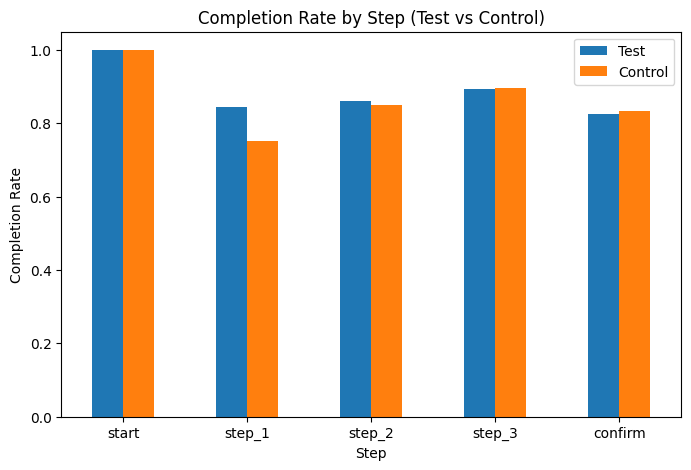

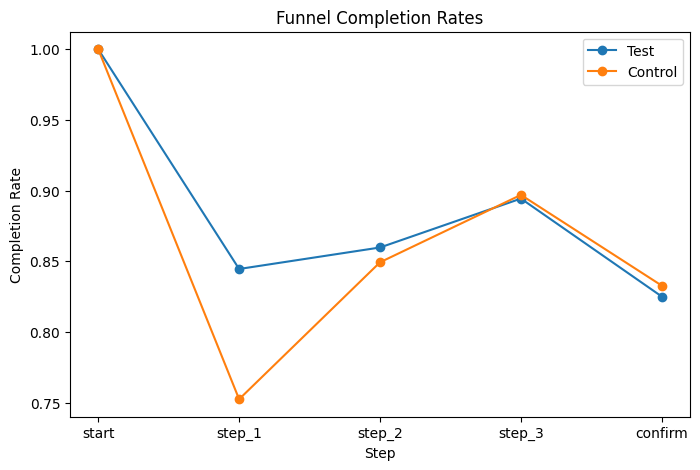

-44.857997455337774
We fail to reject the null hypothesis


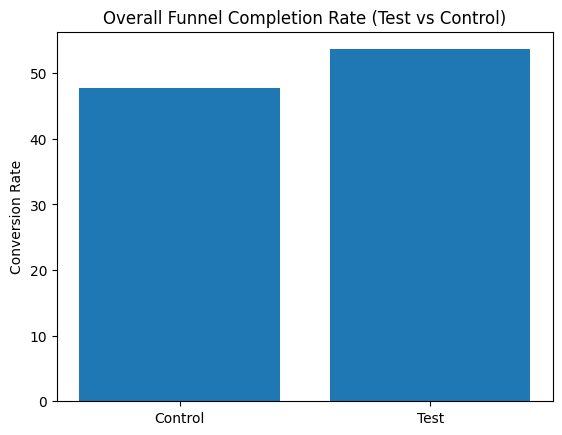

In [27]:
#merging data frames on the completion rates for control and test to make EDA analysis easier

cr_by_steps = pd.merge(test_steps_cr, control_steps_cr, on="step", how="outer")
cr_by_steps

cr_by_steps = cr_by_steps.drop(["attempts_x", "completions_x", "attempts_y", "completions_y"], axis=1)
cr_by_steps = cr_by_steps.rename(columns={'completion_rate_x': 'completion_rate_test', 'completion_rate_y': 'completion_rate_control'})

order = ["start", "step_1", "step_2", "step_3", "confirm"]

cr_by_steps["step"] = pd.Categorical(
    cr_by_steps["step"],
    categories=order,
    ordered=True)

cr_by_steps = cr_by_steps.sort_values("step")

cr_by_steps.set_index("step").plot(kind="bar", figsize=(8,5))

plt.ylabel("Completion Rate")
plt.xlabel("Step")
plt.title("Completion Rate by Step (Test vs Control)")
plt.xticks(rotation=0)
plt.legend(["Test", "Control"])

plt.show()



plt.figure(figsize=(8,5))

plt.plot(cr_by_steps["step"], cr_by_steps["completion_rate_test"], marker="o", label="Test")
plt.plot(cr_by_steps["step"], cr_by_steps["completion_rate_control"], marker="o", label="Control")

plt.ylabel("Completion Rate")
plt.xlabel("Step")
plt.title("Funnel Completion Rates")
plt.legend()

plt.show()


# Two-proportion z-test to check whether the improvement at step_1 is real or just due to random variation using a significance level of 5%
# H0: p(test) =< p(control) --> New website design does not improve step 1 completion 
# H1: p(test) > p(control) --> New website design does improve step 1 completion 


P_1 = 27885/33018
P_2 = 23169/30793
p1 = (27885 + 23169)/(33018 + 30793)

Z1 = ((P_2 - P_1) - 0.05) / np.sqrt(p1 * (1 - p1) * (1/30793 + 1/33018))

print(Z1)
if Z1 > 1.96: 
    print ("We reject the null hypothesis")
else: 
    print("We fail to reject the null hypothesis")



cr_by_steps.to_csv("cr_by_steps.csv")



labels = ["Control", "Test"]
rates = [rate_control, rate_test]

plt.bar(labels, rates)
plt.ylabel("Conversion Rate")
plt.title("Overall Funnel Completion Rate (Test vs Control)")
plt.show()

### 2. Drop-off rate 

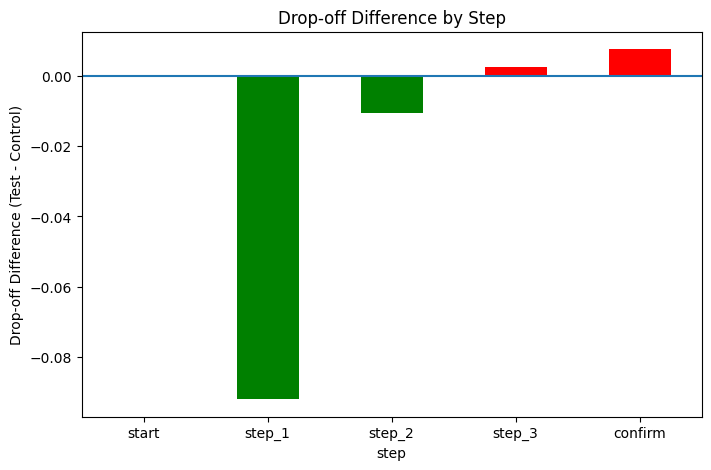

In [28]:
cr_by_steps["dropoff_test"] = 1 - cr_by_steps["completion_rate_test"]
cr_by_steps["dropoff_control"] = 1 - cr_by_steps["completion_rate_control"]

cr_by_steps["dropoff_diff"] = (cr_by_steps["dropoff_test"] - cr_by_steps["dropoff_control"])
colors = ["green" if x < 0 else "red" for x in cr_by_steps["dropoff_diff"]]
cr_by_steps.set_index("step")["dropoff_diff"].plot(kind="bar", color=colors,figsize=(8,5))

plt.axhline(0)
plt.ylabel("Drop-off Difference (Test - Control)")
plt.title("Drop-off Difference by Step")
plt.xticks(rotation=0)

plt.show()

The experiment significantly reduces drop-off at step_1 (~9%), suggesting the new design improves initial engagement. Later funnel steps show minimal differences, and the final confirmation step slightly underperforms in the test group

### 3. Demographics: 

Shape: (50487, 10)

Variation counts:
variation
Test       26961
Control    23526
Name: count, dtype: int64

Means by group:
            clnt_age  clnt_tenure_yr  num_accts            bal  calls_6_mnth  \
variation                                                                      
Control    47.498427       12.087860   2.259925  150151.900186      3.129176   
Test       47.163922       11.982901   2.249917  148962.605032      3.061941   

           logons_6_mnth  
variation                 
Control         6.166242  
Test            6.101851  

Medians by group:
           clnt_age  clnt_tenure_yr  num_accts       bal  calls_6_mnth  \
variation                                                                
Control        48.5            11.0        2.0  66031.45           3.0   
Test           47.5            11.0        2.0  65468.36           3.0   

           logons_6_mnth  
variation                 
Control              6.0  
Test                 6.0  

Age description by gr

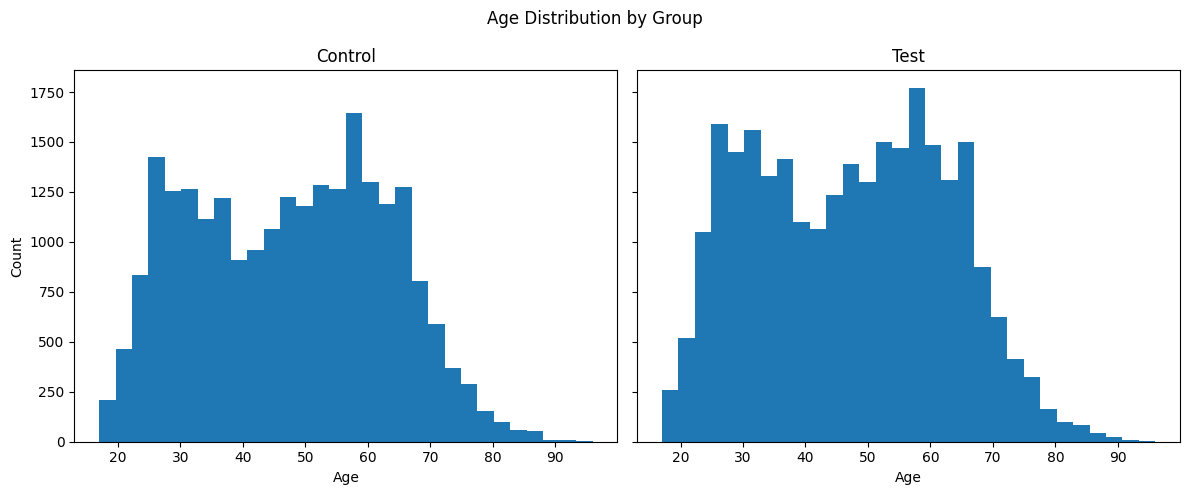

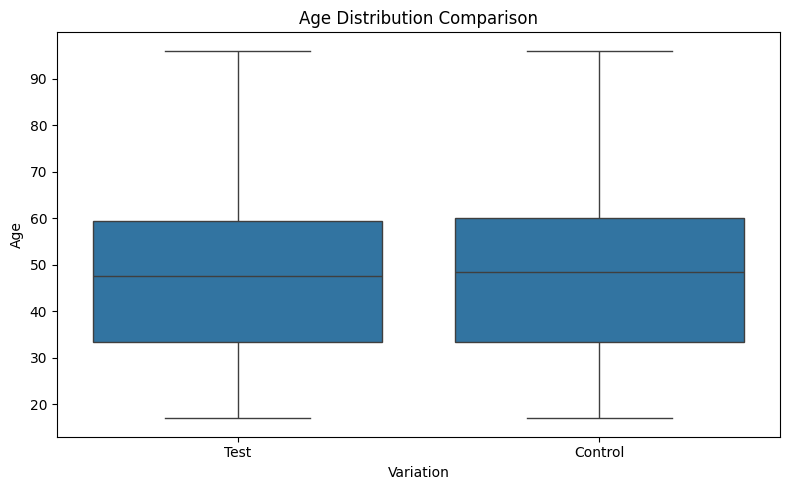

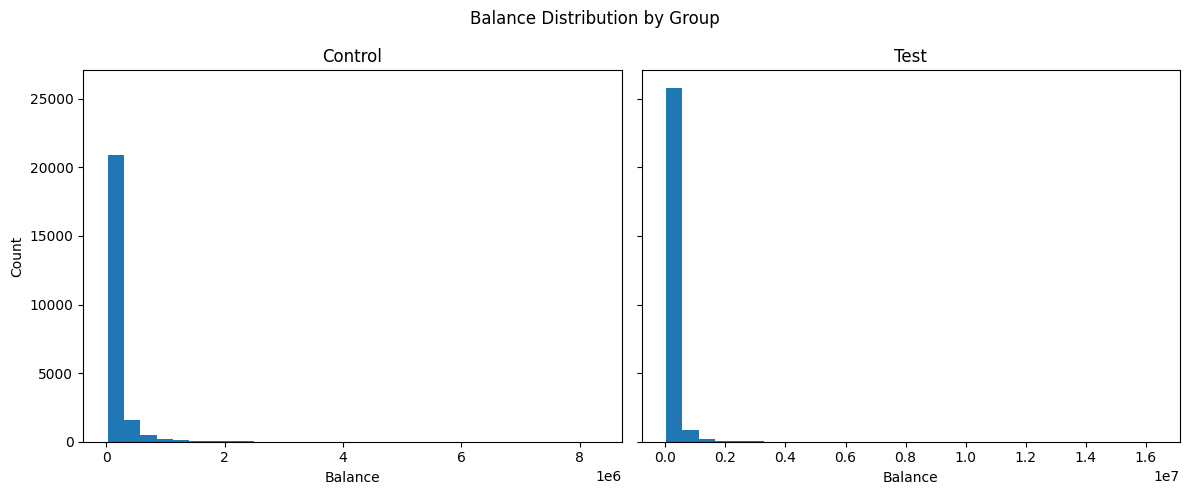

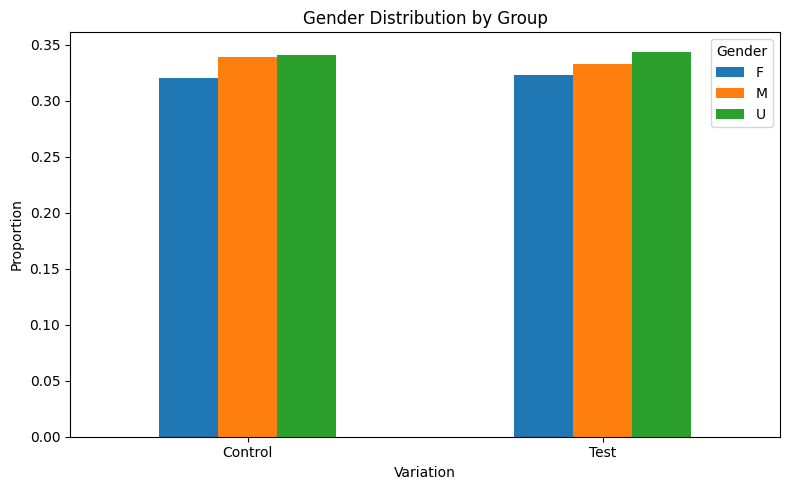

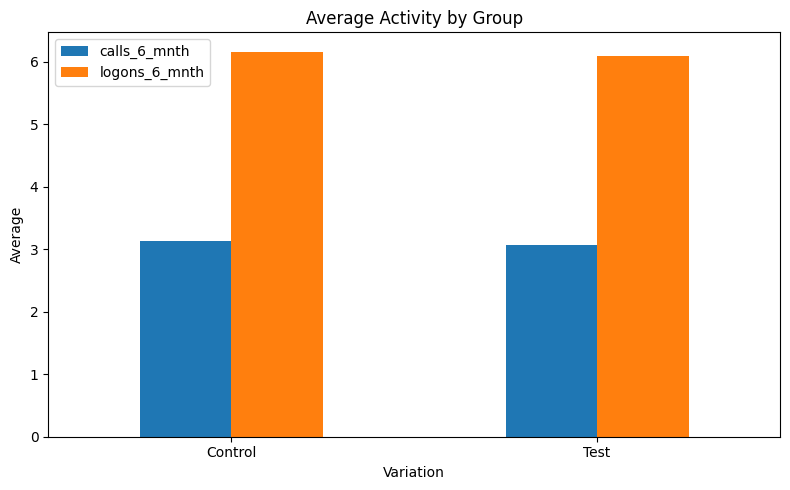


Age t-test
t-statistic: 2.416145610586789
p-value: 0.015689311849750105

Balance t-test
t-statistic: 0.44134212058143396
p-value: 0.6589672273121786

Gender chi-square test
chi2 statistic: 1.9039223438187003
p-value: 0.3859833010778912

Interpretation:
- Age differs significantly between Control and Test.
- No significant balance difference between Control and Test.
- No significant gender distribution difference between Control and Test.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# 1. Load the correct datasets
df_demo = pd.read_csv('../data/clean/df_final_demo.csv')
df_exp = pd.read_csv('../data/clean/df_final_experiment_clients_clean.csv')

# 2. Merge demographics with experiment group
df = df_demo.merge(df_exp, on='client_id', how='inner')

# 3. Keep only Control and Test
df = df[df['variation'].isin(['Control', 'Test'])].copy()

# 4. Quick check
print("Shape:", df.shape)
print("\nVariation counts:")
print(df['variation'].value_counts())

# 5. Summary statistics
print("\nMeans by group:")
print(df.groupby('variation')[[
    'clnt_age',
    'clnt_tenure_yr',
    'num_accts',
    'bal',
    'calls_6_mnth',
    'logons_6_mnth'
]].mean())

print("\nMedians by group:")
print(df.groupby('variation')[[
    'clnt_age',
    'clnt_tenure_yr',
    'num_accts',
    'bal',
    'calls_6_mnth',
    'logons_6_mnth'
]].median())

print("\nAge description by group:")
print(df.groupby('variation')['clnt_age'].describe())

print("\nGender distribution by group:")
print(pd.crosstab(df['variation'], df['gendr'], normalize='index'))

# 6. Visualizations

# Age distribution - fixed version (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, group in enumerate(['Control', 'Test']):
    subset = df[df['variation'] == group]
    axes[i].hist(subset['clnt_age'], bins=30)
    axes[i].set_title(group)
    axes[i].set_xlabel('Age')

axes[0].set_ylabel('Count')
plt.suptitle('Age Distribution by Group')
plt.tight_layout()
plt.show()

# Optional cleaner age comparison
plt.figure(figsize=(8, 5))
sns.boxplot(x='variation', y='clnt_age', data=df)
plt.title('Age Distribution Comparison')
plt.xlabel('Variation')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# Balance distribution - fixed version (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, group in enumerate(['Control', 'Test']):
    subset = df[df['variation'] == group]
    axes[i].hist(subset['bal'], bins=30)
    axes[i].set_title(group)
    axes[i].set_xlabel('Balance')

axes[0].set_ylabel('Count')
plt.suptitle('Balance Distribution by Group')
plt.tight_layout()
plt.show()

# Gender distribution
gender_dist = pd.crosstab(df['variation'], df['gendr'], normalize='index')
gender_dist.plot(kind='bar', figsize=(8, 5))
plt.title('Gender Distribution by Group')
plt.xlabel('Variation')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Activity comparison
activity = df.groupby('variation')[['calls_6_mnth', 'logons_6_mnth']].mean()
activity.plot(kind='bar', figsize=(8, 5))
plt.title('Average Activity by Group')
plt.xlabel('Variation')
plt.ylabel('Average')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Hypothesis testing

# Age: t-test
control_age = df[df['variation'] == 'Control']['clnt_age']
test_age = df[df['variation'] == 'Test']['clnt_age']
t_stat_age, p_value_age = ttest_ind(control_age, test_age, nan_policy='omit')

print("\nAge t-test")
print("t-statistic:", t_stat_age)
print("p-value:", p_value_age)

# Balance: t-test
control_bal = df[df['variation'] == 'Control']['bal']
test_bal = df[df['variation'] == 'Test']['bal']
t_stat_bal, p_value_bal = ttest_ind(control_bal, test_bal, nan_policy='omit')

print("\nBalance t-test")
print("t-statistic:", t_stat_bal)
print("p-value:", p_value_bal)

# Gender: chi-square test
gender_table = pd.crosstab(df['variation'], df['gendr'])
chi2, p_value_gender, dof, expected = chi2_contingency(gender_table)

print("\nGender chi-square test")
print("chi2 statistic:", chi2)
print("p-value:", p_value_gender)

# 8. Interpretation
alpha = 0.05

print("\nInterpretation:")
if p_value_age < alpha:
    print("- Age differs significantly between Control and Test.")
else:
    print("- No significant age difference between Control and Test.")

if p_value_bal < alpha:
    print("- Balance differs significantly between Control and Test.")
else:
    print("- No significant balance difference between Control and Test.")

if p_value_gender < alpha:
    print("- Gender distribution differs significantly between Control and Test.")
else:
    print("- No significant gender distribution difference between Control and Test.")

### 4. Completion Time

In [30]:
df_control = pd.read_csv("df_control_updated.csv")
df_test = pd.read_csv("df_test_updated.csv")

df = pd.concat([df_test, df_control])
df.head()
df.isnull().sum()
df.nunique()
df['process_step'].unique()
# Droping missing values
df = df.dropna(subset=["process_step"])
df.info()
# converting the "date_time" into a datetime type
df["date_time"] = pd.to_datetime(df["date_time"])
# Sort data
df = df.sort_values(["visit_id", "date_time"])


# Ordering the steps
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["step_num"] = df["process_step"].map(step_order)
# Keep only After last 'start'
last_start = (
    df[df["process_step"] == "start"]
    .groupby("visit_id")["date_time"]
    .max()
    .reset_index()
    .rename(columns={"date_time": "last_start_time"})
)

df = df.merge(last_start, on="visit_id", how="left")

df = df[df["date_time"] >= df["last_start_time"]]
# Considering only last 'confirm'
last_confirm = (
    df[df["process_step"] == "confirm"]
    .groupby("visit_id")["date_time"]
    .max()
    .reset_index()
    .rename(columns={"date_time": "last_confirm_time"})
)

df = df.merge(last_confirm, on="visit_id", how="left")
# Applying confirm filter only if exists
f = df[
    (df["last_confirm_time"].isna()) | 
    (df["date_time"] <= df["last_confirm_time"])
]
# Computing time difference
df["next_time"] = df.groupby("visit_id")["date_time"].shift(-1)

df["step_duration"] = (df["next_time"] - df["date_time"]).dt.total_seconds()
# Removing only last rows
df = df.dropna(subset=["step_duration"])
# Aggregating
df_agg = df.groupby(
    ["visit_id", "process_step", "variation"]
)["step_duration"].mean().reset_index()
df_agg.head()
# Let's drop confirm has it can be misleading
df_agg = df_agg[df_agg["process_step"] != "confirm"]

<class 'pandas.DataFrame'>
Index: 275378 entries, 0 to 125093
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         275378 non-null  int64  
 1   clnt_tenure_yr    275285 non-null  float64
 2   clnt_tenure_mnth  275285 non-null  float64
 3   clnt_age          275285 non-null  float64
 4   gendr             275285 non-null  str    
 5   num_accts         275285 non-null  float64
 6   bal               275285 non-null  float64
 7   calls_6_mnth      275285 non-null  float64
 8   logons_6_mnth     275285 non-null  float64
 9   variation         275378 non-null  str    
 10  visitor_id        275378 non-null  str    
 11  visit_id          275378 non-null  str    
 12  process_step      275378 non-null  str    
 13  date_time         275378 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 31.5 MB


#### Visualisations: 

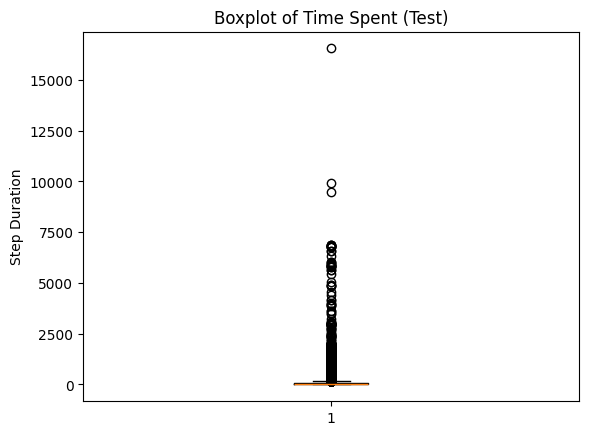

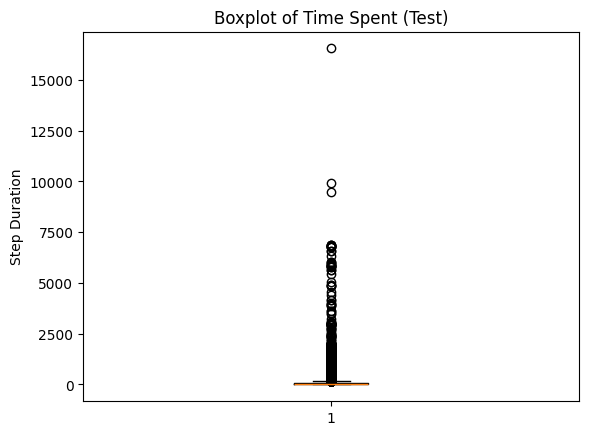

  variation process_step  step_duration
0   Control        start      35.242046
1   Control       step_1      34.502739
2   Control       step_2      89.317049
3   Control       step_3     112.111816
4      Test        start      28.358186
5      Test       step_1      36.412732
6      Test       step_2      85.422477
7      Test       step_3      98.124348


In [31]:
import matplotlib.pyplot as plt

plt.boxplot(df_agg["step_duration"].dropna())
plt.title("Boxplot of Time Spent (Test)")
plt.ylabel("Step Duration")
plt.show()
# Removing outliers
Q1 = df_agg["step_duration"].quantile(0.25)
Q3 = df_agg["step_duration"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_agg[
    (df_agg["step_duration"] >= lower_bound) &
    (df_agg["step_duration"] <= upper_bound)
]

plt.boxplot(df_agg["step_duration"].dropna())
plt.title("Boxplot of Time Spent (Test)")
plt.ylabel("Step Duration")
plt.show()

df_agg["step_duration"].describe()
upper_bound = df_agg["step_duration"].quantile(0.99)

df_clean = df_agg[df_agg["step_duration"] <= upper_bound]
df_clean["step_duration"].max()


##Average time for each step across all visits
df_avg = df_clean.groupby(["variation", "process_step"])["step_duration"].mean().reset_index()
print(df_avg)


#### ANOVA - Within each group

- H₀ (Null Hypothesis): All step completion times are the same within the group
- H₁ (Alternative Hypothesis): All step completion times differs within the group

In [32]:
from scipy.stats import f_oneway

steps = ["start", "step_1", "step_2", "step_3"]

# TEST group
test_data = [
    df_clean[(df_clean["variation"] == "Test") & (df_clean["process_step"] == step)]["step_duration"]
    for step in steps
]

f_stat_test, p_value_test = f_oneway(*test_data)

print("Test group ANOVA p-value:", p_value_test)


# CONTROL group
control_data = [
    df_clean[(df_clean["variation"] == "Control") & (df_clean["process_step"] == step)]["step_duration"]
    for step in steps
]

f_stat_control, p_value_control = f_oneway(*control_data)

print("Control group ANOVA p-value:", p_value_control)

Test group ANOVA p-value: 0.0
Control group ANOVA p-value: 0.0


**Conclusions:** 

To evaluate whether completion times differ across the steps of the process within each group, a one-way ANOVA test was performed separately for the Test and Control groups.

For both groups, the results yielded extremely small p-values (p < 0.001, reported as 0.0 due to rounding), indicating strong evidence against the null hypothesis.

Therefore, we reject the null hypothesis that all step completion times are equal within each group.

This means that there are statistically significant differences in the average time spent across the different steps of the process in both the Test and Control groups.

Step duration varies significantly across the funnel in both groups, confirming non-uniform user effort throughout the process.

#### T-TEST
**Test vs Control**

Null Hypothesis ($H_0$)): For each step of the process, the mean completion time is equal between the Test and Control groups.

Alternative Hypothesis ($H_a$)): For each step of the process, the mean completion time differs between the Test and Control groups.

In [33]:
from scipy.stats import ttest_ind

steps = ["start", "step_1", "step_2", "step_3"]

for step in steps:
    test_vals = df_clean[
        (df_clean["variation"] == "Test") &
        (df_clean["process_step"] == step)
    ]["step_duration"]

    control_vals = df_clean[
        (df_clean["variation"] == "Control") &
        (df_clean["process_step"] == step)
    ]["step_duration"]

    t_stat, p_value = ttest_ind(test_vals, control_vals, equal_var=False)

    print(f"{step} → p-value: {p_value}")

start → p-value: 8.900845966064448e-36
step_1 → p-value: 2.5492195989787133e-05
step_2 → p-value: 2.724089257083751e-07
step_3 → p-value: 1.8685698758535584e-31


Conclusions:

There are statistically significant differences in completion times between the Test and Control groups at every step of the process. Therefore, we reject the null hypothesis that for each step of the process, the mean completion time is equal between the Test and Control groups.

This indicates that the new interface has a consistent and measurable impact on user behavior across the entire funnel.

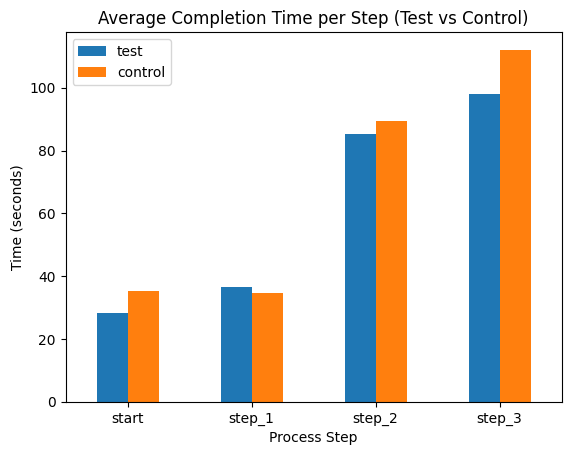

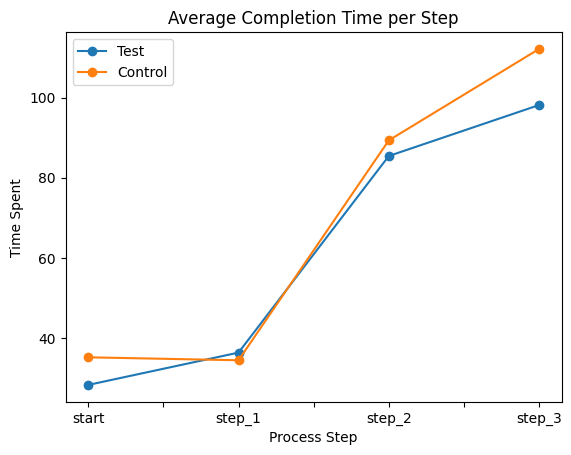

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    "step": ["start", "step_1", "step_2", "step_3"],
    "test": [28.36, 36.41, 85.42, 98.12],
    "control": [35.24, 34.50, 89.32, 112.11]
})

data = data.set_index("step")

data.plot(kind="bar")

plt.title("Average Completion Time per Step (Test vs Control)")
plt.xlabel("Process Step")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)

plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Your data
test = pd.Series({
    "start": 28.358186,
    "step_1": 36.412732,
    "step_2": 85.422477,
    "step_3":  98.124348
})

control = pd.Series({
    "start": 35.242046,
    "step_1": 34.502739,
    "step_2": 89.317049,
    "step_3": 112.111816
})

# Combine
df_plot = pd.DataFrame({
    "Test": test,
    "Control": control
})

# Plot
df_plot.plot(marker='o')
plt.title("Average Completion Time per Step")
plt.ylabel("Time Spent")
plt.xlabel("Process Step")
plt.xticks(rotation=0)
plt.show()

df_avg.to_csv("completion_time_francisca.csv", index=False)

### ERROR RATE 

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# ── Step 1: Load clean data ──────────────────────────────────────────────────
web_data = pd.read_csv('../data/clean/clean_web_data.csv')
experiment_clients = pd.read_csv('../data/clean/df_final_experiment_clients_clean.csv')

# Merge to bring in the variation column
web_data = web_data.merge(experiment_clients, on='client_id', how='inner')

# Split into control and test
df_control = web_data[web_data['variation'] == 'Control'].copy()
df_test    = web_data[web_data['variation'] == 'Test'].copy()

print("Control shape:", df_control.shape)
print("Test shape:   ", df_test.shape)

# ── Step 2: Define funnel order ──────────────────────────────────────────────
step_order = {
    'start':   0,
    'step_1':  1,
    'step_2':  2,
    'step_3':  3,
    'confirm': 4
}

# ── Step 3: Error rate per step ──────────────────────────────────────────────
def error_rate_per_step(df, label):
    df = df.copy()
    print(f"\n--- Processing {label} group ---")

    df['step_num'] = df['process_step'].map(step_order)
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    df['prev_step'] = df.groupby(['client_id', 'visit_id'])['step_num'].shift(1)
    df['error'] = df['step_num'] < df['prev_step']

    step_errors = df.groupby('process_step')['error'].mean().reset_index()
    step_errors.columns = ['process_step', f'error_rate_{label.lower()}']
    print(f"Error rate per step:\n{step_errors}")

    return df, step_errors

df_control_flagged, control_step_errors = error_rate_per_step(df_control, "Control")
df_test_flagged,    test_step_errors    = error_rate_per_step(df_test,    "Test")

# ── Step 4: Merge & order for comparison ────────────────────────────────────
order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
comparison = control_step_errors.merge(test_step_errors, on='process_step', how='outer')
comparison = comparison.set_index('process_step').loc[order].reset_index()

print("\n--- Step-by-step error rate comparison ---")
print(comparison)

# ── Step 5: Overall error rates ──────────────────────────────────────────────
control_n      = df_control_flagged['visit_id'].nunique()
test_n         = df_test_flagged['visit_id'].nunique()
control_errors = df_control_flagged.groupby('visit_id')['error'].any().sum()
test_errors    = df_test_flagged.groupby('visit_id')['error'].any().sum()
control_rate   = control_errors / control_n
test_rate      = test_errors    / test_n

print(f"\nControl error rate: {control_rate:.4f}")
print(f"Test error rate:    {test_rate:.4f}")

# ── Step 6: Hypothesis test ──────────────────────────────────────────────────
z_stat, p_value = proportions_ztest([control_errors, test_errors], [control_n, test_n])

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: The difference in error rates is statistically significant.")
else:
    print("Fail to reject H0: No significant difference in error rates detected.")

# ── Step 7: Interpretation ───────────────────────────────────────────────────
if test_rate < control_rate:
    print("\nInterpretation: The Test group has a LOWER error rate — the new UI reduces user errors.")
else:
    print("\nInterpretation: The Test group has a HIGHER error rate — the new UI does not reduce errors.")

# ── Step 8: Plot ─────────────────────────────────────────────────────────────
x     = np.arange(len(comparison['process_step']))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison['error_rate_control'], width, label='Control', color='steelblue')
plt.bar(x + width/2, comparison['error_rate_test'],    width, label='Test',    color='coral')

plt.xticks(x, comparison['process_step'], rotation=45)
plt.title('Error Rate per Step: Control vs Test')
plt.ylabel('Error Rate')
plt.xlabel('Process Step')
plt.legend()
plt.tight_layout()
plt.show()

# ── Step 9: Export ───────────────────────────────────────────────────────────
df_control_flagged.to_csv('df_control_updated.csv', index=False)
df_test_flagged.to_csv('df_test_updated.csv', index=False)

print("Done! Files saved next to your notebook.")

ModuleNotFoundError: No module named 'statsmodels'

In [36]:
print(experiment_clients.columns.tolist())

NameError: name 'experiment_clients' is not defined

In [37]:
import os

for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

control_step_errors.to_csv('control_error_rates.csv', index=False)
test_step_errors.to_csv('test_error_rates.csv', index=False)

print("Done!")

./df_test_updated.csv
./cr_by_steps.csv
./error_rates_combined.csv
./test_error_rates.csv
./df_control_updated.csv
./completion_time_francisca.csv
./df_combined.csv
./control_error_rates.csv
./cr_steps1.csv
./.ipynb_checkpoints/df_control_updated-checkpoint.csv
./.ipynb_checkpoints/df_test-checkpoint.csv
./.ipynb_checkpoints/df_control-checkpoint.csv


NameError: name 'control_step_errors' is not defined

#### Hypothesis testing 

In [38]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# ── Hypothesis Test: Error Rate ──────────────────────────────────────────────
# H0: error rate is the same in both groups (new UI made no difference)
# H1: error rate is different between groups (new UI made a difference)

print("=" * 55)
print("HYPOTHESIS TEST: ERROR RATE (Control vs Test)")
print("=" * 55)
print(f"Control: {control_errors} errors out of {control_n} sessions ({control_rate:.2%})")
print(f"Test:    {test_errors} errors out of {test_n} sessions ({test_rate:.2%})")

# Z-test
z_stat, p_value = proportions_ztest([control_errors, test_errors], [control_n, test_n])
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ Reject H0 (p < {alpha}): The difference in error rates is statistically significant.")
else:
    print(f"\n❌ Fail to reject H0 (p >= {alpha}): No significant difference detected.")

# ── Confidence Intervals ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("95% CONFIDENCE INTERVALS")
print("=" * 55)

ci_control = proportion_confint(control_errors, control_n, alpha=0.05, method='normal')
ci_test    = proportion_confint(test_errors,    test_n,    alpha=0.05, method='normal')

print(f"Control: ({ci_control[0]:.2%}, {ci_control[1]:.2%})")
print(f"Test:    ({ci_test[0]:.2%}, {ci_test[1]:.2%})")

# ── Practical Significance ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("PRACTICAL SIGNIFICANCE")
print("=" * 55)

diff = test_rate - control_rate
print(f"Difference in error rate (Test - Control): {diff:.2%}")

if diff > 0:
    print("The Test group has a HIGHER error rate — the new UI introduces more user errors.")
else:
    print("The Test group has a LOWER error rate — the new UI reduces user errors.")

# ── Per-step conclusions ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("PER-STEP ANALYSIS")
print("=" * 55)
for _, row in comparison.iterrows():
    step = row['process_step']
    ctrl = row['error_rate_control']
    test = row['error_rate_test']
    diff_step = test - ctrl
    direction = "higher ⚠️" if diff_step > 0 else "lower ✅"
    print(f"{step}: Control={ctrl:.2%}, Test={test:.2%} → Test is {abs(diff_step):.2%} {direction}")

ModuleNotFoundError: No module named 'statsmodels'

In [39]:
comparison.to_csv('error_rates_combined.csv', index=False)
print("Done!")

NameError: name 'comparison' is not defined

In [40]:
# Convert to Tableau-friendly format (long format)
error_rate_step_tableau = comparison.melt(
    id_vars='process_step',
    value_vars=['error_rate_control', 'error_rate_test'],
    var_name='variation',
    value_name='error_rate'
)

# Clean names
error_rate_step_tableau['variation'] = error_rate_step_tableau['variation'].replace({
    'error_rate_control': 'Control',
    'error_rate_test': 'Test'
})

# Save file
error_rate_step_tableau.to_csv('../data/clean/error_rate_by_step_tableau.csv', index=False)

print("CSV exported successfully!")

NameError: name 'comparison' is not defined